In [ ]:
!pip install igraph
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import itertools
import operator
import networkx as nx

from scipy import stats


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 28.1 MB/s eta 0:00:00


"\nfig, ax = plt.subplots()\nig.plot(\n    g,\n    target=ax,\n    layout='circle',\n    vertex_color='steelblue',\n    vertex_label=range(g.vcount()),\n    edge_width=1,\n    edge_color='#666',\n    edge_align_label=True,\n    edge_background='white'\n)\n"

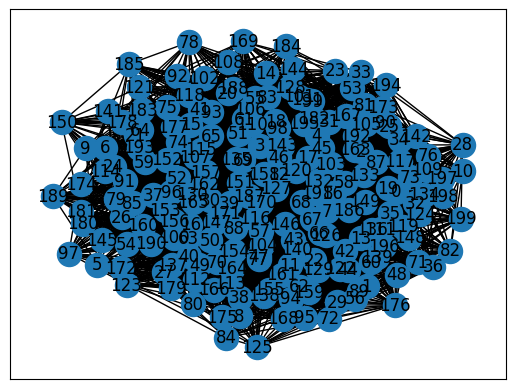

In [ ]:
from networkx.generators.random_graphs import erdos_renyi_graph
import networkx as nx

v = 200
p = 0.20
G = erdos_renyi_graph(v, p)
#G = nx.barabasi_albert_graph(100, 2)
E=[]
for i in G.edges:
  E.append(i)

allowedWeightValues = list(range(1,5))  #allowedWeightValues = [1, 2, 3, 4, 5]
noOfEdges = len(E)
g = ig.Graph(v, E)


nx.draw_networkx(G)
"""
fig, ax = plt.subplots()
ig.plot(
    g,
    target=ax,
    layout='circle',
    vertex_color='steelblue',
    vertex_label=range(g.vcount()),
    edge_width=1,
    edge_color='#666',
    edge_align_label=True,
    edge_background='white'
)
"""

In [ ]:
def findSEPR(path, WT):
  sEPR = max(WT)
  for i in range(len(path[0])-1):
    if (path[0][i],path[0][i+1]) in E:
      index = E.index((path[0][i],path[0][i+1]))
    else:
      index = E.index((path[0][i+1],path[0][i]))
    if sEPR >= WT[index]:
      sEPR = WT[index]
  return sEPR
def updatePathWeight(path, pathWeight, updateFactor):
  for i in range(len(path[0])-1):
    if (path[0][i],path[0][i+1]) in E:
      index = E.index((path[0][i],path[0][i+1]))
    else:
      index = E.index((path[0][i+1],path[0][i]))
    pathWeight[index] = pathWeight[index] - updateFactor
  return pathWeight

In [ ]:
def intersection(lst1, lst2):
    temp = set(lst2)
    lst3 = [value for value in lst1 if value in temp]
    return lst3

In [ ]:
AllPath = dict()
def getAllShortestPath(NodePairs):
  AllPath.clear()
  for (x,y) in NodePairs:
    if AllPath.get(x) == None:
      AllPath[x] = {}
    RX = [p for p in nx.all_simple_paths(G, x, y,2)]
    RX.sort(key=len)
    AllPath[x][y] = RX

In [ ]:
AllPathsEPR = dict()
def getAllsEPR(NodePairs, WT):
  AllPathsEPR.clear()
  for (x,y) in NodePairs:
    if AllPathsEPR.get(x) == None:
      AllPathsEPR[x] = {}
    if AllPathsEPR[x].get(y) == None:
      AllPathsEPR[x][y] = []
    for p in AllPath[x][y]:
      AllPathsEPR[x][y].append(findSEPR([p],WT))

In [ ]:
def getKthShortestPath(source, destination, k):
  RX = AllPath[source][destination]
  if k < len(RX):
    return [RX[k]], len(RX[k])-1
  else:
    return 0,0;
#shortestPath, shortestPathLength = getKthShortestPath(22,67,405)
#print(shortestPath, shortestPathLength)

In [ ]:
AllSortedsEPRs = dict()
AllSortedPathSEPR = dict()
def sortPathsBasedOnsEPRs(NodePairs):
  AllSortedsEPRs.clear()
  for (x,y) in NodePairs:
    S = sorted(zip(AllPathsEPR[x][y], AllSortedPathSEPR[x][y]), key = lambda x: (-x[0]))
    if AllSortedsEPRs.get(x) == None:
      AllSortedsEPRs[x] = {}
    if AllSortedsEPRs[x].get(y) == None:
      AllSortedsEPRs[x][y] = []
    AllSortedsEPRs[x][y], AllSortedPathSEPR[x][y] = [list(t) for t in zip(*S)]

In [ ]:
def HighsEPR(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  Kth = 0
  for i in range(len(RD)):
    for k in range(len(AllSortedPathSEPR[RDN[i][0]][RDN[i][1]])):
      t = RST[i]
      path = AllSortedPathSEPR[RDN[i][0]][RDN[i][1]][k]
      pathL = len(path) - 1
      if pathL > 0:
        if pathL == 1:
            TimeRemaining = RDT[i] - 1
        else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
        while t< TimeRemaining and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight([path], WT[t], sEPR)
              if pathL == 1:
                t = t + 1
              else:
                t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight([path], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
          if pathL == 1:
            TimeRemaining = RDT[i] - 1
          else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
  return EPRServed, SCHD, DServed

In [ ]:
def QoSScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  Kth = 0
  while sum(RD) > 0 and sum(RsPathL) > 0:
    S = sorted(zip(RD, RDT, RsPathL, RsPaths, RDN, RST), key = lambda x: (x[2], x[1], x[0]))
    RD,RDT,RsPathL,RsPaths,RDN, RPI = [list(t) for t in zip(*S)]
    for i in range(len(RD)):
      t = RST[i]
      pathL = RsPathL[i]
      if pathL > 0:
        #print(RsPaths[i])
        if pathL == 1:
            TimeRemaining = RDT[i] - 1
        else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
        while t< TimeRemaining and RD[i]>0:
          sEPR = findSEPR(RsPaths[i], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight(RsPaths[i], WT[t], sEPR)
              if pathL == 1:
                t = t + 1
              else:
                t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight(RsPaths[i], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
          if pathL == 1:
            TimeRemaining = RDT[i] - 1
          else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
    Kth+=1
    RsPaths = list()
    RsPathL = list()
    for k in RDN:
      shortestPath, shortestPathLength = getKthShortestPath(k[0], k[1], Kth)
      RsPaths.append(shortestPath)
      RsPathL.append(shortestPathLength)
  return EPRServed, SCHD, DServed

In [ ]:
# Uses all_shortest_paths -> updated to all_simple_paths
def PIScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RPI, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      if pathL < math.pow(2, RDT[i]) and RD[i]>0:
        t = RST[i]
        if pathL == 1:
          TimeRemaining = RDT[i] - 1
        else:
          TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
        while t<TimeRemaining and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              runningTime = math.ceil(math.log2(pathL))
              tempT = t
              while tempT < t+runningTime:
                WT[tempT] = updatePathWeight([path], WT[tempT], sEPR)
                tempT += 1
              if pathL == 1:
                t += 1
              else:
                t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              runningTime = math.ceil(math.log2(pathL))
              tempT = t
              while tempT < t+runningTime:
                WT[tempT] = updatePathWeight([path], WT[tempT], RD[i])
                tempT += 1
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
          if pathL == 1:
            TimeRemaining = RDT[i] - 1
          else:
            TimeRemaining = RDT[i]-math.ceil(math.log2(pathL))
  return EPRServed, SCHD, DServed

In [ ]:
# Uses all_simple_paths
def splitScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    #print(RX)
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      #print(path)
      if pathL < math.pow(2, RDT[i]-RST[i]) and RD[i]>0:
        t = RST[i]
        while t<(RDT[i]-math.ceil(math.log(pathL))) and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight([path], WT[t], sEPR)
              t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight([path], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
  return EPRServed, SCHD, DServed

In [ ]:
def naive(SN):
  #Find the shortest path for the demand
  #Try to reserve resources on the shortest path
  #If not possible, loop over n such paths without splitting and try to reserve resources
  #If no path is available, mark it failed
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    # print('shortest path')
    # RX = [p for p in nx.all_shortest_paths(G, RDN[i][0], RDN[i][1])]
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    path_counter = 0
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      breakFlag = False
      if pathL < math.pow(2, RDT[i]-RST[i]):
        path_counter += 1
        t = RST[i]
        while t<(RDT[i]-math.ceil(math.log(pathL))):
          sEPR = findSEPR([path], WT[t])
          # print(f'Debugging Naive:------ For Demand: {( RDN[i][0], RDN[i][1])} Path: {path} and time: {t} Req EPR: {RD[i]} and sEPR: {sEPR}')
          if RD[i]<sEPR:
            EPRServed += RD[i]
            WT[t] = updatePathWeight([path], WT[t], RD[i])
            SCHD[t].append((RDN[i],RD[i]))
            RD[i] = 0
            DServed += 1
            breakFlag=True
            break
          else:
            t += 1
        if breakFlag:
          break
    #print(f'Naive:------ Demand: {( RDN[i][0], RDN[i][1])} and available no. of paths: {len(RX)}, unuseful no. of paths: {len(RX)-path_counter}')
  #print(f'EPRServed: {EPRServed}, DServed: {DServed}')
  return EPRServed, SCHD, DServed

**Increase No of EPRs**

In [ ]:
k = 2000
max_demand_size = 11
lowerBound = 1
step = 1
iterations = 50

demand_increment_range = np.arange(lowerBound, max_demand_size, step)
num_points = len(demand_increment_range)

# MODIFIED: 2D NumPy matrices (iterations x num_points) to hold raw trial metrics
all_dres1 = np.zeros((iterations, num_points))
all_dres2 = np.zeros((iterations, num_points))
all_dres3 = np.zeros((iterations, num_points))
all_dres4 = np.zeros((iterations, num_points))
all_dres5 = np.zeros((iterations, num_points))

all_eprres1 = np.zeros((iterations, num_points))
all_eprres2 = np.zeros((iterations, num_points))
all_eprres3 = np.zeros((iterations, num_points))
all_eprres4 = np.zeros((iterations, num_points))
all_eprres5 = np.zeros((iterations, num_points))

for iteration in range(iterations):
  print(f'iteration: {iteration}')

  W = random.choices(allowedWeightValues, k=noOfEdges)
  DN = random.sample(list((x,y) for x,y in itertools.product(range(v), repeat = 2) if x!=y and x<y), k)
  for i in DN:
      shortestPath = g.get_shortest_paths(i[0], to=i[1], output="vpath")
      if(len(shortestPath[0])>3):
        index = DN.index((i[0], i[1]))
        del DN[index]
  noOfDemands = len(DN)
  D = random.choices(list(range(1,3)), k=noOfDemands)
  DT = random.choices(list(range(5,10)), k=noOfDemands)
  ST = random.choices(list(range(0,5)), k=noOfDemands)
  getAllShortestPath(DN)
  getAllsEPR(DN, W)
  AllSortedPathSEPR = AllPath.copy()
  sortPathsBasedOnsEPRs(DN)

  for p_idx, i in enumerate(demand_increment_range):
    D = [x+1 for x in D]
    sPaths = list()
    sPathL = []
    for node_pair in DN:
      shortestPath = g.get_shortest_paths(node_pair[0], to=node_pair[1], output="vpath")
      sPaths.append(shortestPath)
      sPathL.append(len(shortestPath[0])-1)

    m = 0
    Paths = sPaths
    P = [0 for _ in range(len(Paths))]
    for l in Paths:
      P[m] = []
      for q in l:
        for idx in range(len(q)-1):
          P[m].append((q[idx], q[idx+1]))
      m += 1

    m = 0
    PI = [0 for _ in range(len(P))]
    for item_i in P:
      for item_j in P:
        if intersection(item_i, item_j):
          PI[m] += 1
        else:
          j_r = [(y,x) for (x,y) in item_j]
          if intersection(item_i, j_r):
            PI[m] += 1
      m += 1

    NS = [a for a in zip(D, DT, sPathL, sPaths, DN, ST)]
    S = sorted(zip(D, DT, sPathL, sPaths, DN, ST), key = lambda x: (x[1], x[0], x[2]))
    PI_S = sorted(zip(D, DT, sPathL, sPaths, DN, PI, ST), key = lambda x: (x[5], x[2], x[0], x[1]))

    eprserved1, schd1, dserved1 = splitScheduling(S)
    eprserved4, schd4, dserved4 = PIScheduling(PI_S)
    eprserved2, schd2, dserved2 = naive(NS)
    eprserved3, schd3, dserved3 = QoSScheduling(NS)
    eprserved5, schd5, dserved5 = HighsEPR(S)

    # Store exact trial outputs in matrices
    all_eprres1[iteration, p_idx] = eprserved1 / sum(D)
    all_eprres2[iteration, p_idx] = eprserved2 / sum(D)
    all_eprres3[iteration, p_idx] = eprserved3 / sum(D)
    all_eprres4[iteration, p_idx] = eprserved4 / sum(D)
    all_eprres5[iteration, p_idx] = eprserved5 / sum(D)

    all_dres1[iteration, p_idx] = dserved1 / len(D)
    all_dres2[iteration, p_idx] = dserved2 / len(D)
    all_dres3[iteration, p_idx] = dserved3 / len(D)
    all_dres4[iteration, p_idx] = dserved4 / len(D)
    all_dres5[iteration, p_idx] = dserved5 / len(D)

iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
iteration: 5
iteration: 6
iteration: 7
iteration: 8
iteration: 9
iteration: 10
iteration: 11
iteration: 12
iteration: 13
iteration: 14
iteration: 15
iteration: 16
iteration: 17
iteration: 18
iteration: 19
iteration: 20
iteration: 21
iteration: 22
iteration: 23
iteration: 24
iteration: 25
iteration: 26
iteration: 27
iteration: 28
iteration: 29
iteration: 30
iteration: 31
iteration: 32
iteration: 33
iteration: 34
iteration: 35
iteration: 36
iteration: 37
iteration: 38
iteration: 39
iteration: 40
iteration: 41
iteration: 42
iteration: 43
iteration: 44
iteration: 45
iteration: 46
iteration: 47
iteration: 48
iteration: 49


In [ ]:
from scipy import stats
def compute_mean_and_ci(data_matrix, confidence=0.95):
    means = np.mean(data_matrix, axis=0)
    sem = stats.sem(data_matrix, axis=0)
    h = sem * stats.t.ppf((1 + confidence) / 2., iterations - 1)
    return means, h

In [ ]:
mean_dres1, ci_dres1 = compute_mean_and_ci(all_dres1)
mean_dres2, ci_dres2 = compute_mean_and_ci(all_dres2)
mean_dres3, ci_dres3 = compute_mean_and_ci(all_dres3)
mean_dres4, ci_dres4 = compute_mean_and_ci(all_dres4)
mean_dres5, ci_dres5 = compute_mean_and_ci(all_dres5)

In [ ]:
import numpy as np

np.savez('CI_EPR.npz',
         x_axis=demand_increment_range,
         mean_dres1=mean_dres1, ci_dres1=ci_dres1,
         mean_dres2=mean_dres2, ci_dres2=ci_dres2,
         mean_dres3=mean_dres3, ci_dres3=ci_dres3,
         mean_dres4=mean_dres4, ci_dres4=ci_dres4,
         mean_dres5=mean_dres5, ci_dres5=ci_dres5)
print("Data saved successfully to simulation_results.npz")

Data saved successfully to simulation_results.npz


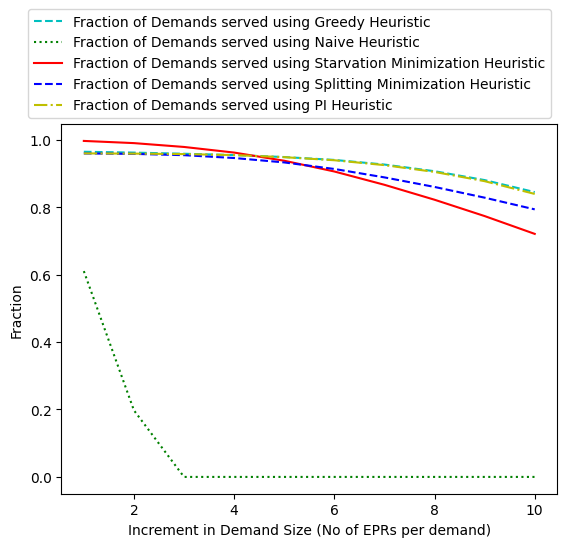

In [ ]:
plt.figure(figsize=(8, 6))

# Define series parameters
series_config = [
    (mean_dres1, ci_dres1, 'c', 'dashed', 'Fraction of Demands served using Greedy Heuristic'),
    (mean_dres2, ci_dres2, 'g', 'dotted', 'Fraction of Demands served using Naive Heuristic'),
    (mean_dres3, ci_dres3, 'r', 'solid', 'Fraction of Demands served using Starvation Avoidance Heuristic'),
    (mean_dres4, ci_dres4, 'b', 'dashed', 'Fraction of Demands served using Splitting Minimization Heuristic'),
    (mean_dres5, ci_dres5, 'y', 'dashdot', 'Fraction of Demands served using PI Heuristic'),
]

for mean_val, ci_val, color, style, label in series_config:
    plt.plot(demand_increment_range, mean_val, color=color, label=label, linestyle=style)
    # ADDED: Render semi-transparent 95% CI bands
    plt.fill_between(demand_increment_range, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.5)

plt.xlabel("Increment in Demand Size (No of EPRs per demand)")
plt.ylabel("Fraction")
plt.legend(bbox_to_anchor=(0.5, 1.27), loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('vEPR.png', bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
import numpy as np

# Load the npz archive
with np.load("CI_EPR.npz") as data:
    # Read the x-axis
    demand_increment_range = data["x_axis"]

    # Read mean and confidence intervals for each heuristic
    mean_dres1, ci_dres1 = data["mean_dres1"], data["ci_dres1"]
    mean_dres2, ci_dres2 = data["mean_dres2"], data["ci_dres2"]
    mean_dres3, ci_dres3 = data["mean_dres3"], data["ci_dres3"]
    mean_dres4, ci_dres4 = data["mean_dres4"], data["ci_dres4"]
    mean_dres5, ci_dres5 = data["mean_dres5"], data["ci_dres5"]

# Variables remain available in memory after exiting the 'with' block
print("Loaded x-axis:", demand_increment_range)

Loaded x-axis: [ 1  2  3  4  5  6  7  8  9 10]


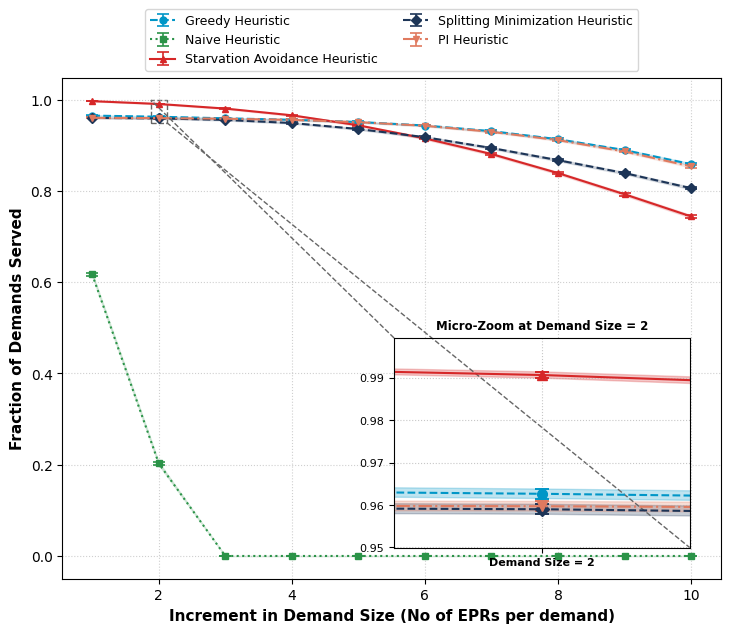

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8.5, 6.5))

series_config = [
    (mean_dres1, ci_dres1, '#0096c7', '--', 'o', 'Greedy Heuristic'),
    (mean_dres2, ci_dres2, '#2b9348', ':', 's', 'Naive Heuristic'),
    (mean_dres3, ci_dres3, '#d62728', '-', '^', 'Starvation Avoidance Heuristic'),
    (mean_dres4, ci_dres4, '#1d3557', '--', 'D', 'Splitting Minimization Heuristic'),
    (mean_dres5, ci_dres5, '#e07a5f', '-.', 'v', 'PI Heuristic'),
]

# --- Main Plot ---
for mean_val, ci_val, color, style, marker, label in series_config:
    ax.errorbar(
        demand_increment_range, mean_val, yerr=ci_val, color=color, linestyle=style,
        marker=marker, markersize=5, capsize=4, capthick=1.2, elinewidth=1.2,
        label=f'{label}'
    )
    ax.fill_between(demand_increment_range, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.15)

ax.set_xlabel("Increment in Demand Size (No of EPRs per demand)", fontsize=11, fontweight='bold')
ax.set_ylabel("Fraction of Demands Served", fontsize=11, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=2, fontsize=9, frameon=True)

# --- Inset Box (Positioned lower-right for clear visibility) ---
axins = inset_axes(ax, width="45%", height="42%", loc="lower right", borderpad=2.2)

# Target nEPR = 2 (Index 1)
target_idx = 1
target_x = demand_increment_range[target_idx]

# --- Plot ONLY Top-Performing Heuristics in Inset ---
for mean_val, ci_val, color, style, marker, label in series_config:
    if 'Naive' in label:  # Exclude baseline so Y-axis stretches strictly around overlapping top curves
        continue
    axins.errorbar(
        demand_increment_range, mean_val, yerr=ci_val, color=color, linestyle=style,
        marker=marker, markersize=7, capsize=5, capthick=1.4, elinewidth=1.4
    )
    axins.fill_between(demand_increment_range, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.25)

# --------------------------------------------------------------------------
# TIGHT BOUNDS AROUND TOP CLUSTER AT nEPR = 2
# --------------------------------------------------------------------------
axins.set_xlim(target_x - 0.12, target_x + 0.12)

# Dynamically set Y-limits using top heuristics only (~0.94 to 1.00)
top_y = [m[target_idx] for m, _, _, _, _, label in series_config if 'Naive' not in label]
top_ci = [c[target_idx] for _, c, _, _, _, label in series_config if 'Naive' not in label]

y_min = min(y - ci for y, ci in zip(top_y, top_ci))
y_max = max(y + ci for y, ci in zip(top_y, top_ci))

axins.set_ylim(y_min - 0.008, y_max + 0.008)

# --- Formatting Inset Axis ---
axins.set_xticks([target_x])
axins.set_xticklabels([f'Demand Size = {target_x}'], fontsize=8.5, fontweight='bold')
axins.yaxis.set_major_locator(MaxNLocator(5))
axins.tick_params(axis='both', labelsize=8)
axins.grid(True, linestyle=':', alpha=0.7)
axins.set_title("Micro-Zoom at Demand Size = 2", fontsize=8.5, fontweight='bold')

# Clean connecting lines pointing strictly to the top cluster box
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", ls="--")

plt.savefig('vEPR_MicroZoom_Fixed.png', bbox_inches='tight', dpi=500)
plt.show()

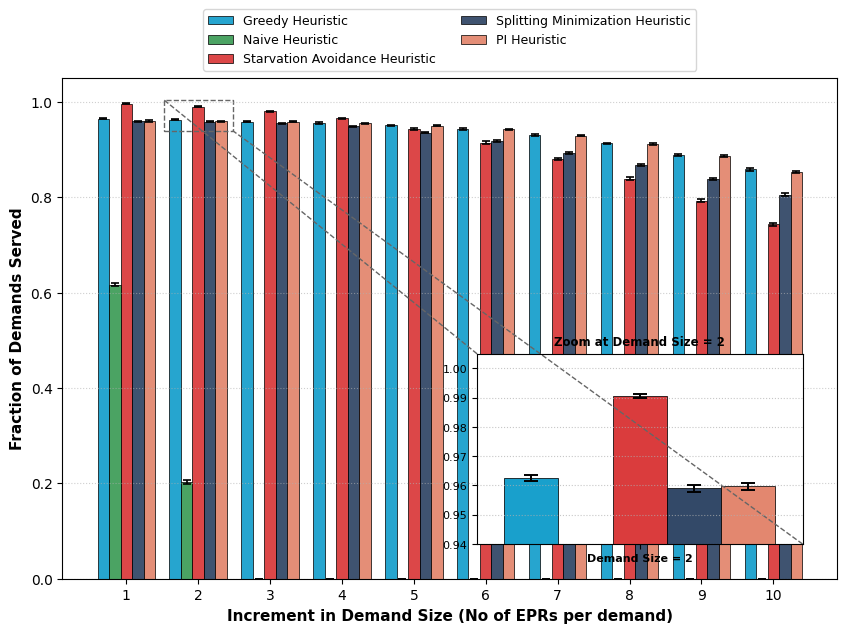

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(10, 6.5))

series_config = [
    (mean_dres1, ci_dres1, '#0096c7', 'Greedy Heuristic'),
    (mean_dres2, ci_dres2, '#2b9348', 'Naive Heuristic'),
    (mean_dres3, ci_dres3, '#d62728', 'Starvation Avoidance Heuristic'),
    (mean_dres4, ci_dres4, '#1d3557', 'Splitting Minimization Heuristic'),
    (mean_dres5, ci_dres5, '#e07a5f', 'PI Heuristic'),
]

x = np.arange(len(demand_increment_range))
num_series = len(series_config)
bar_width = 0.8 / num_series

# --- Main Grouped Bar Chart ---
for i, (mean_val, ci_val, color, label) in enumerate(series_config):
    offset = x + (i - (num_series - 1) / 2) * bar_width
    ax.bar(
        offset, mean_val, width=bar_width, label=label, color=color,
        edgecolor='black', linewidth=0.6, alpha=0.85,
        yerr=ci_val, capsize=3,
        error_kw={'ecolor': 'black', 'elinewidth': 1.2, 'capthick': 1.2}
    )

ax.set_xlabel("Increment in Demand Size (No of EPRs per demand)", fontsize=11, fontweight='bold')
ax.set_ylabel("Fraction of Demands Served", fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(demand_increment_range)
ax.set_ylim(0.0, 1.05)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.legend(bbox_to_anchor=(0.5, 1.15), loc='upper center', ncol=2, fontsize=9, frameon=True)

# --- Clean Inset Zoom for Bar Chart at nEPR = 2 (Index 1) ---
axins = inset_axes(ax, width="42%", height="38%", loc="lower right", borderpad=2.5)

target_idx = 1  # Target nEPR = 2
offset_at_2 = x[target_idx] + (np.arange(num_series) - (num_series - 1) / 2) * bar_width

for i, (mean_val, ci_val, color, label) in enumerate(series_config):
    if 'Naive' in label:
        continue  # Exclude low baseline so top bars scale cleanly

    axins.bar(
        offset_at_2[i], mean_val[target_idx], width=bar_width, color=color,
        edgecolor='black', linewidth=0.6, alpha=0.9,
        yerr=ci_val[target_idx], capsize=5,
        error_kw={'ecolor': 'black', 'elinewidth': 1.4, 'capthick': 1.4}
    )

# Tight zoom framing around the top bars at nEPR = 2
axins.set_xlim(offset_at_2[0] - bar_width, offset_at_2[-1] + bar_width)
axins.set_ylim(0.94, 1.005)

axins.set_xticks([x[target_idx]])
axins.set_xticklabels([f'Demand Size = {demand_increment_range[target_idx]}'], fontsize=8.5, fontweight='bold')
axins.tick_params(axis='both', labelsize=8)
axins.grid(True, axis='y', linestyle=':', alpha=0.7)
axins.set_title("Zoom at Demand Size = 2", fontsize=8.5, fontweight='bold')

# Assigned to `_` to suppress raw object text output
_ = mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", ls="--")

plt.savefig('vEPR_GroupedBar_Zoom.png', bbox_inches='tight', dpi=500)
plt.show()